### Middleware
#### Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for following:
1. Tracking agent behavior with logging, analytics, and debugging.
2. Transforming prompts, tool selection, and output formatting.
3. Adding retries, fallbacks, and early termination logic.
4. Applying rate limits, guardrails, and PII detection.


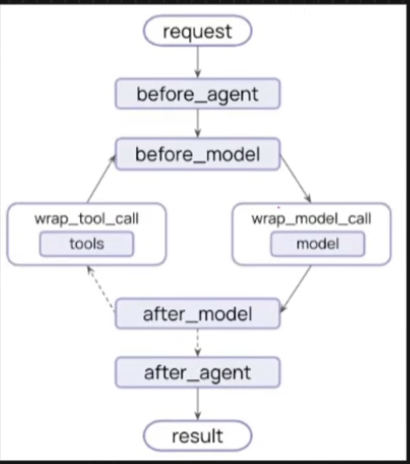

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]= os.getenv("GROQ_API_KEY")


#### Summarization Middleware
It automatically summarize conversation history when apporaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:
1. Long-running conversations that exceed context windows.
2. Multi-turn dialogues with extensive history.
3. Applications where preserving full conversation context matters.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Message Based Summarization
agent = create_agent(
  model= "groq:openai/gpt-oss-120b",
  checkpointer=InMemorySaver(),
  middleware=[
    SummarizationMiddleware(
      model= "groq:openai/gpt-oss-120b",
      trigger =("messages",10),
      keep=("messages",4)
    ),
  ],
)

# Run with thread id
config = {"configurable": {"thread_id": "test-1"}}

# Alternate test data
questions =[
  "what is 2+2?",
  "what is 3*4?",
  "what is 100/4?",
  "what is 10-3?",
  "what is 4*4?",
  "what is 5+5?",
  "what is 6*6?",
  "what is 7-2?",
  "what is 8/2?",
  "what is 9*9?",
  "what is 10-5?",
]
for q in questions:
  response = agent.invoke({"messages": [HumanMessage(content=q)]}, config)
  print(f"Messages: {response}")
  print(f"Messages: {len(response['messages'])}\n")


### Token Size

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city: str) -> str:
  """Search hotels - returns long response to use more tokens."""
  return f"""Hotels in {city}:
  1.Grantd hotel - 5 star, $350/night, spa, gym and pool.
  2. City Inn - 3 star, $150/night, free breakfast and wifi.
  3. Budget Stay - 2 star, $80/night, basic amenities.
  """

agent = create_agent(
  model= "groq:openai/gpt-oss-120b",
  checkpointer=InMemorySaver(),
  tools=[search_hotel],
  middleware=[
    SummarizationMiddleware(
      model= "groq:openai/gpt-oss-120b",
      trigger =("tokens",1300),
      keep=("tokens",200)
    ),
  ],
)
# Run with thread id
config = {"configurable": {"thread_id": "test-2"}}

# Token counter (approximate)
def count_tokens(messages):
  total_chars = sum(len(str(m.content)) for m in messages)
  return total_chars // 4  # 4 chars = 1 token (approximate)

# run test
cities = ["New York", "Los Angeles", "Chicago", "Houston", "Phoenix", "Philadelphia", "San Antonio"]
for city in cities:
  response = agent.invoke({"messages": [HumanMessage(content=f"Search hotels in {city}")]}, config)
  tokens = count_tokens(response['messages'])
  print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
  print(f"{city}: {response['messages']}\n")

### Fraction

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotel(city: str) -> str:
  """Search hotels - returns long response to use more tokens."""
  return f"Hotels in {city}: Grand hotel $350, city inn $150, budget stay $80."

# LOW fraction for testing!
agent = create_agent(
  model= "groq:openai/gpt-oss-120b",
  checkpointer=InMemorySaver(),
  tools=[search_hotel],
  middleware=[
    SummarizationMiddleware(
      model= "groq:openai/gpt-oss-120b",
      trigger =("fraction", 0.005),  # 0.5% = ~ 640 tokens
      keep=("fraction", 0.002),  # 0.2% = ~ 256 tokens
    ),
  ],
)
# Run with thread id
config = {"configurable": {"thread_id": "test-3"}}

# Token counter (approximate)
def count_tokens(messages):
  total_chars = sum(len(str(m.content)) for m in messages)
  return total_chars // 4  # 4 chars = 1 token (approximate)

# run test
cities = ["New York", "Los Angeles", "Chicago", "Houston", "Phoenix", "Philadelphia", "San Antonio"]
for city in cities:
  response = agent.invoke({"messages": [HumanMessage(content=f"Search hotels in {city}")]}, config)
  tokens = count_tokens(response['messages'])
  fraction = tokens / 128_000  # 128k tokens = 100% of model context
  print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} messages")
  print(f"{city}: {response['messages']}\n")

#### Human in the Loop Middleware
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
1. High-stakes operations requiring human approval (e.g. database writes, financial transactions).
2. Compliance workflows where human oversight is mandatory.
3. Long-running conversations where human feedback guides the agent

In [44]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its id"""
    return f"Email content for id: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email"""
    return f"Email sent to {recipient} with subject '{subject}' and body '{body}'"

agent = create_agent(
    model="groq:openai/gpt-oss-120b",
    tools=[read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
      HumanInTheLoopMiddleware(
        interrupt_on={
          "send_email_tool": {
              "allowed_decisions": ["approve", "reject", "edit"],
          },
          "read_email_tool": False,
        }
      ),
    ],
)

## Approve

In [ ]:
config = {"configurable": {"thread_id": "test_approve"}}    
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@example.com with subject 'Test Email' and body 'This is a test email.'")]},
    config
)
# Step 2.1: Approve
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Approving...")
    result = agent.invoke(
        Command(
            resume= {
                "decisions":[
                    {"type": "approve"}
                ]
            }
        ),
        config
    )
    print(f"Result: {result['messages'][-1].content}")

In [ ]:
result

## Reject

In [ ]:
config = {"configurable": {"thread_id": "test_reject"}}    
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@example.com with subject 'Test Email' and body 'This is a test email.'")]},
    config
)
# Step 2.2: Reject
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Approving...")
    result = agent.invoke(
        Command(
            resume= {
                "decisions":[
                    {"type": "reject"}
                ]
            }
        ),
        config
    )
    print(f"Result: {result['messages'][-1].content}")

In [ ]:
result

## Edit

In [45]:
config = {"configurable": {"thread_id": "test_edit"}}    
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@example.com with subject 'Test Email' and body 'This is a test email.'")]},
    config
)
# Step 2.3: Edit
from langgraph.types import Command
if "__interrupt__" in result:
    print("Paused! Approving...")
    result = agent.invoke(
        Command(
            resume= {
                "decisions":[
                    {
                        "type": "edit", 
                        "edited_action":{
                            "name": "send_email_tool",
                            "args": {
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This is the corrected email body."
                            }
                        }
                    }
                ]
            }
        ),
        config
    )
    print(f"Result: {result['messages'][-1].content}")

Paused! Approving...
Result: I’m sorry about that mistake. I’ll send the correct email now.

Sending email to **john@example.com** with the subject **“Test Email”** and the body **“This is a test email.”**.


In [46]:
result

{'messages': [HumanMessage(content="Send email to john@example.com with subject 'Test Email' and body 'This is a test email.'", additional_kwargs={}, response_metadata={}, id='5b6f1067-c26b-4efc-b1c7-1bdc8dae1130'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user wants to send an email. Use send_email_tool.', 'tool_calls': [{'id': 'fc_4175d567-bf20-439c-a02d-cddf998c3656', 'function': {'arguments': '{"body":"This is a test email.","recipient":"john@example.com","subject":"Test Email"}', 'name': 'send_email_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 177, 'total_tokens': 240, 'completion_time': 0.132621998, 'completion_tokens_details': {'reasoning_tokens': 14}, 'prompt_time': 0.007307031, 'prompt_tokens_details': None, 'queue_time': 0.369422105, 'total_time': 0.139929029}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'tool